<a href="https://colab.research.google.com/github/aniqarahman/portfolio/blob/main/co2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font size = 6> **Vehicles and CO2 Emissions** </font>

For this project, I decided to pull a dataset from Kaggle where each row lists a car from popular brans such as Audi or BMW, the model, and various features of the car that affect its CO2 emissions.  I will first conduct some EDA to get a better understanding of the data and create basic visualizations.

The last column "CO2 Emissions(g/km)" is the carbon emission for each car and is what I am trying to model with the following models. The first model I use is a Random Forest Regressor and try to predict carbon emissions from all the features. The second model I use is a Random Forest Classifier to label each row as a "Low", "Medium", or "High" emission vehicle. Lastly, for both models, I use cross validation and other metrics such as MAE or MSE to assess the validity of the models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

In [4]:
co = pd.read_csv('co2.csv')
co.head() #loading the dataset in

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


<font size =4> **EDA/Basic Visualizations**</font>

In the following cell, I grab the top 10 popular class vehicles and visualize the distribution of each vehicle class' carbon emissions with box plots. The SUV-standard has the highest median carbon emissions at around 300 g/km and the station wagon had the lowest carbon emissions at around 200 g/km.

Text(0.5, 1.0, 'Box Plots of Top 10 Vehicle Classes v. Carbon Emissions')

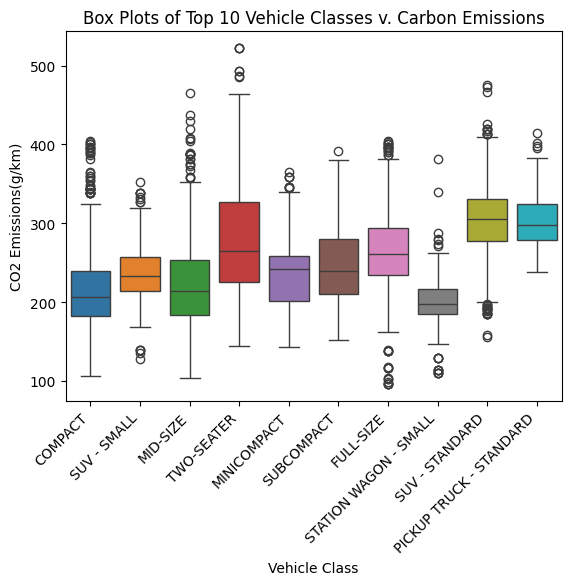

In [5]:
co_veh_class_list = list(co['Vehicle Class'].value_counts().head(10).index)
co_veh_class = co[co["Vehicle Class"].isin(co_veh_class_list)]
sns.boxplot(x = 'Vehicle Class', y = 'CO2 Emissions(g/km)',  hue = 'Vehicle Class', data = co_veh_class)
plt.xticks(rotation=45, ha='right')
plt.title("Box Plots of Top 10 Vehicle Classes v. Carbon Emissions")

In [6]:
co["Fuel Type"].value_counts()
#will drop N when creating visualization because of low count

,count
Fuel Type,
X,3637
Z,3202
E,370
D,175
N,1


The next column I chose to visualize was the Fuel type column and seeing how fuel type impacts emissions. Since fuel types are pretty central to the emission of a car, I chose to visualize it with a violin plot so I can get a more detailed visual of the distribution for each fuel type compared to a box plot. For example, even though the median for fuel type D is around 250 g/km, its distribution is slightly bimodal in nature.

Text(0.5, 1.0, 'Violin Plot of CO2 Emissions v. Fuel Type')

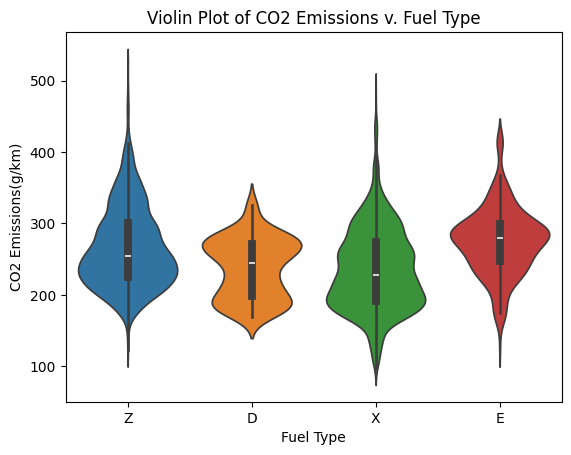

In [7]:
co_violin = co[co["Fuel Type"] != "N"]
sns.violinplot(y = 'CO2 Emissions(g/km)', x = 'Fuel Type', hue ='Fuel Type', data = co_violin)
plt.title("Violin Plot of CO2 Emissions v. Fuel Type")
#since the mean is pretty similar for each fuel type, looking at the distribution helps as well

Another column I chose to look at was Transmission since the type of transmission also plays a key role in the carbon emissions of a car. Similarly, to what I did for Vehicle Class, I chose the top 10 popular transmissions and plotted box plots.

Text(0.5, 1.0, 'Box Plot of CO2 Emissions v. Transmission')

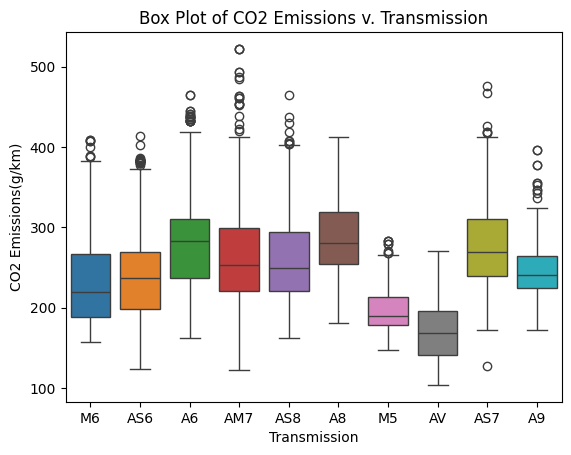

In [8]:
transmission_list = list(co["Transmission"].value_counts().head(10).index)
co_transmission = co[co["Transmission"].isin(transmission_list)]
sns.boxplot(x = 'Transmission', y = 'CO2 Emissions(g/km)', hue = 'Transmission', data = co_transmission)
plt.title("Box Plot of CO2 Emissions v. Transmission")

The last visualization I chose to do was a joint plot of Engine Size and Carbon Emissions. The reason why I chose to do a joint plot was because I wanted to see the relationship between engine size and carbon emissions as well as seeing the individual distributions for each feature. As shown below, the relationship between the two features are relatively linear, which indicates there indeed exists a relationship between engine size and carbon emissions.

Text(0.5, 1.2, 'Joint Plot of CO2 Emissions v. Engine Size')

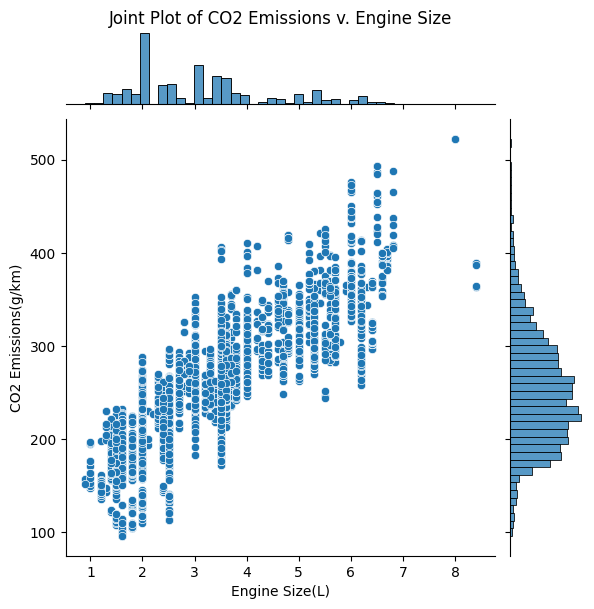

In [9]:
sns.jointplot(x = 'Engine Size(L)', y = 'CO2 Emissions(g/km)', data = co)
plt.title("Joint Plot of CO2 Emissions v. Engine Size", y = 1.2)

In [10]:
co["Vehicle Class"].value_counts()

,count
Vehicle Class,
SUV - SMALL,1217
MID-SIZE,1133
COMPACT,1022
SUV - STANDARD,735
FULL-SIZE,639
SUBCOMPACT,606
PICKUP TRUCK - STANDARD,538
TWO-SEATER,460
MINICOMPACT,326


<font size =5> **Random Forest Regression**</font>

I will use a random forest regression model to predict the amount of carbon emission for each car based on each feature. I chose to do a random forest regression because what this model is doing is it is building various different trees with each tree focusing on a different set of features (i.e one tree emphasizes engine size whereas another tree emphasizes fuel type) and taking the average of each tree at the end. This form of training means the model is learning specific rules of the dataset much more closely without the risk of overfitting that comes with a linear regression model. Because there is no risk of overfitting, the need to feature engineer is virtually gone, which is why I one-hot encode the whole table (minus the target variable which is the carbon emissions column) and train it with this new mega-table. Also, since the dataset is only about 7000 rows, it would not be too disastrous to use something as computationally expensive as a random forest regression model over something simpler such as linear regression model.

<font size = 3> **Training Regression Model** </font>

In [11]:
x = pd.get_dummies(co.drop(["CO2 Emissions(g/km)"], axis = 1))
y = co["CO2 Emissions(g/km)"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2)

rfr = RandomForestRegressor()
rfr.fit(x_train, y_train)
y_pred_train = rfr.predict(x_train)
y_pred_test = rfr.predict(x_test)


<font size = 3> **Plotting Regression Model** </font>

I plotted the observed values against the predicted values from the regression model, and judging from the visualization, it is a very robust model. A few cells after, I recorded the MAE, MSE, RMSE, and R^2 scores for the training and test sets to see if it's a good model.

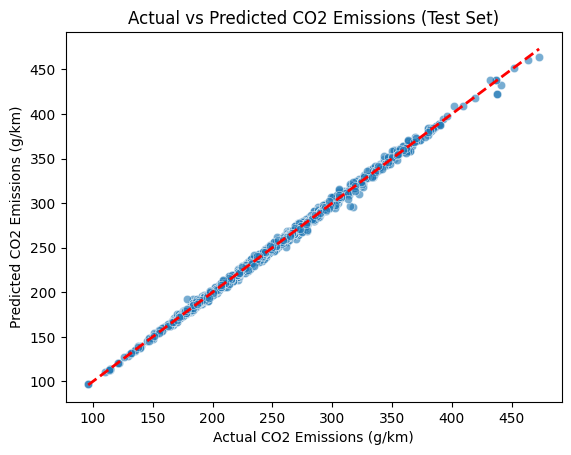

In [12]:
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual CO2 Emissions (g/km)")
plt.ylabel("Predicted CO2 Emissions (g/km)")
plt.title("Actual vs Predicted CO2 Emissions (Test Set)")
plt.show()

<font size = 3> Residual Plot of Regression Model </font>

Another way to measure if how well the regression model fits the data is with a residual plot, which plots the difference between every actual y value and the predicted y value outputted from the model. A good way to visually tell if the model is a good fit is if the residual plot has no discernable pattern (i.e a linear shape) and the points are evenly scattered around 0. Since the points are scattered, mostly around 0, and has no pattern, it's safe to say this model was a good fit for the model.

Text(0.5, 1.0, 'Residual Plot')

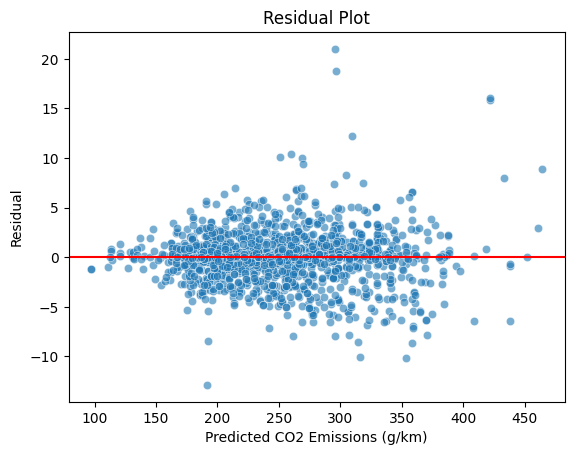

In [13]:
sns.scatterplot(x=y_pred_test, y = y_test - y_pred_test , alpha=0.6)
plt.axhline(0, color = 'r')
plt.xlabel("Predicted CO2 Emissions (g/km)")
plt.ylabel("Residual")
plt.title("Residual Plot")

<font size = 3> Mean Absolute Error (MAE/L1 loss function)</font>

It is the average of the absolute differences between the actual and predicted values, which represents the average amount of error across the dataset. It is important to note MAE preserves the units so it's simple to tell how off the model is from the predicted values. The MAE for both training and test data is extremely low, meaning this model is a good fit according to this metric.

In [14]:
mean_absolute_error(y_train, y_pred_train)

0.7826598624707117

In [15]:
mean_absolute_error(y_test, y_pred_test)

1.7576586030947903

<font size = 3> Mean Squared Error (MSE/L2 function)</font>

It is the average of the square of the differences between the actual and predicted values, which represents the average amount of error and penalizes outliers and errors more than MAE. It is important to note MSE does not preserve the units like MAE because of the squaring. The MSE for the training data is extremely low, which indicates a good fit on the training data. However, since the MSE on the test data is slightly higher than the training data, it would be natural to suspect a slight overfit could be happening. But it's important to note carbon emissions are in the hundreds and the units aren't preserved so being off by 10 isn't enough to deduce the model isn't robust. It could mean, though, there might be some really significant outliers or a few points have a really high errors.

In [16]:
mean_squared_error(y_train, y_pred_train)

1.83082612528951

In [17]:
mean_squared_error(y_test, y_pred_test)

7.0873359558548685

<font size = 3> Root Mean Squared Error (RMSE)</font>

RMSE is taking the root of each MSE to return it to its original units, making this metric arguably more useful for evaluating the model. The test and training RMSEs are considerably low and only off by 1-3 g/km of carbon emissions, which again is a good indicator of a robust model.

In [18]:
root_mean_squared_error(y_train, y_pred_train)

1.3530802360870955

In [19]:
root_mean_squared_error(y_test, y_pred_test)

2.662205092748278

$R^2$ Score

This score denotes the variance in the model and the closer the value is to 1, the better the fit of the regression model is for the data. The outputs of the next two cells are extremely close to 1, which again indicates a good model.

In [20]:
r2_score(y_pred_train, y_train)

0.9994672809173324

In [21]:
r2_score(y_pred_test, y_test)

0.9978740742427531

<font size = 3> K-Fold Cross Validation</font>

This following function was heavily inspired by a function I previously defined in a class project to compute the cross validation of a linear regression. I tweaked a few lines to compute it with a random forest regression instead. Since random forests are more computationally intensive, using more folds meant really long run-times, which is why I chose to use 3 folds instead. The cross validation errors are also low (around 2-3 g/km), which again means the model built is a good fit.

In [22]:
from sklearn.model_selection import KFold

def rmse(y, y_train):
    return (sum((y_train - y)**2)/len(y))**0.5

def compute_CV_error(X_train, Y_train, folds=10):
    model = RandomForestRegressor(random_state= 13)
    kf = KFold(n_splits=folds)
    validation_errors = []

    for train_idx, valid_idx in kf.split(X_train):
        split_X_train, split_X_valid =  X_train.iloc[train_idx],  X_train.iloc[valid_idx]
        split_Y_train, split_Y_valid = Y_train.iloc[train_idx],  Y_train.iloc[valid_idx]

        model.fit(split_X_train, split_Y_train)
        error = rmse(split_Y_valid, model.predict(split_X_valid))
        validation_errors.append(error)

    return validation_errors

In [23]:
compute_CV_error(x_train, y_train, folds=3)
#keeping number of folds low since random forest is much more computationally intensive than logistic regression

[3.363429889958982, 3.381490000888122, 2.6817954891310345]

In [24]:
compute_CV_error(x_test, y_test, folds=3)

[4.282443888246767, 4.496454385112145, 3.961692051953706]

<font size =5> **Random Forest Classification**</font>

https://www.ageco.co.uk/useful-articles/car/what-are-the-co2-emissions-of-my-car/#:~:text=If%20you%20want%20to%20understand,255g%2Fkm%20is%20considered%20high


To build a classifier, I first want to figure what if the CO2 emission of a car is high, medium, or low.
I'm using the aforementioned article. The article states:

"If you want to understand what is considered high or low in terms of petrol/diesel/hybrid emissions, here is a rough guide:
* 150g/km is considered low
* 160 to 255g/km is considered medium
* Above 255g/km is considered high"

Although the article is from UK, I used this article because the EU tends to have stricter rules regarding CO2 emissions and the rough estimates are already converted to g/km, making it much easier to perform calculations. I will be using the ranges listed here to label the co dataframe with "low", "medium" or "high" so I can build a classification model and compare it against these labels.


In [25]:
def co2_level(num):
    if num <= 150:
        return "Low"
    if num >150 and num <255:
        return "Medium"
    if num >= 255:
        return "High"

co1 = co.copy()
co1["Carbon Emission Level"] = co["CO2 Emissions(g/km)"].apply(co2_level)
co1.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Carbon Emission Level
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196,Medium
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221,Medium
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136,Low
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255,High
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244,Medium


In [26]:
co1["Carbon Emission Level"].value_counts()

,count
Carbon Emission Level,
Medium,3965
High,3259
Low,161


I then drop the column with the labels, Carbon Emission Level, and one-hot encode the whole table to build my matrix X. It is important to note that I can use every feature because of the specific nature of random forests and do not need to feature engineer. The carbon emission level column will be my Y column, which I will compare my predicted values with.

In [27]:
x1 = pd.get_dummies(co1.drop(["Carbon Emission Level", "Carbon Emission Level"], axis = 1))
y1 = co1["Carbon Emission Level"]
x_train1, x_test1, y_train1, y_test1 = train_test_split(x1, y1, test_size= 0.1)

rfc = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_split=10, random_state=42)
rfc.fit(x_train1, y_train1)
y_pred_train1 = rfc.predict(x_train1)
y_pred_test1 = rfc.predict(x_test1)

In [29]:
np.mean(y_pred_train1 == y_train1)


np.float64(0.9992476677700872)

In [30]:
np.mean(y_test1 == y_pred_test1)

np.float64(1.0)

In [31]:
def compute_CV_error_rfc(X_train, Y_train, folds=10):
    model = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_split=10) #difference here
    kf = KFold(n_splits=folds)
    validation_errors = []

    for train_idx, valid_idx in kf.split(X_train):
        split_X_train, split_X_valid =  X_train.iloc[train_idx],  X_train.iloc[valid_idx]
        split_Y_train, split_Y_valid = Y_train.iloc[train_idx],  Y_train.iloc[valid_idx]

        model.fit(split_X_train, split_Y_train)
        error =  np.mean(split_Y_valid == model.predict(split_X_valid)) #main difference here from previous cv error function
        validation_errors.append(error)

    return validation_errors



In [32]:
compute_CV_error_rfc(x_train1, y_train1, folds=4)

[np.float64(0.9945848375451264),
 np.float64(0.9957882069795427),
 np.float64(0.9963877182420229),
 np.float64(0.9981938591210114)]

In [33]:
compute_CV_error_rfc(x_test1, y_test1, folds=4)

[np.float64(0.9837837837837838),
 np.float64(0.9513513513513514),
 np.float64(0.9621621621621622),
 np.float64(0.9945652173913043)]

In [34]:
y_train1.map({"High": 1, "Low": 0, "Medium": 0})

,Carbon Emission Level
3954,0
320,0
7312,1
7255,1
1389,1
...,...
4417,1
1625,1
3319,0
6672,1


Text(0.5, 1.0, 'Heatmap')

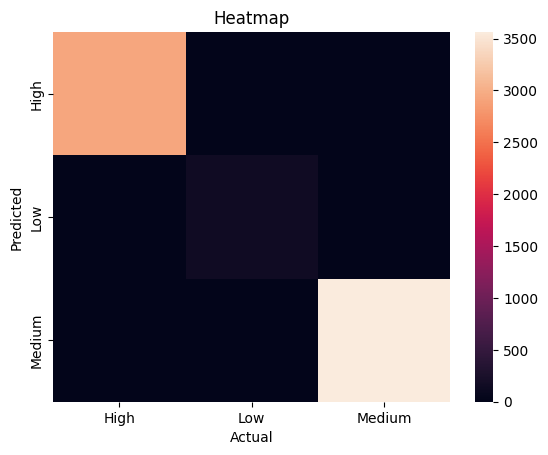

In [35]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train1, y_pred_train1)
sns.heatmap(cm, xticklabels=rfc.classes_, yticklabels=rfc.classes_)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Heatmap")

In [37]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train1, rfc.predict_proba(x_train1), multi_class='ovr', labels=rfc.classes_)

np.float64(0.999996667397023)

This concludes the coding portion of this personal project of mine. I used the results from here to create a slide deck detailing what conclusions I drew from the results from the code and some reflections at the end on my project. Here's the link to my slide deck.

https://docs.google.com/presentation/d/13artHLV_7qSGBc9TYHZQ0gqI1BZ1jCSG5z1fkB2-CIk/edit?slide=id.g39df9b7cd6b_0_204#slide=id.g39df9b7cd6b_0_204
